# 🎨 AestheticScorer — CNN Training Notebook
**ResNet50 + ROI-Align → Aesthetic Score Regression**

**Runtime:** `Runtime → Change runtime type → T4 GPU`

---
**Pipeline:**
1. Install deps & mount Drive
2. Upload dataset (images + labels CSV)
3. Define model (from `model.py`)
4. Train with MSE + Ranking loss
5. Evaluate & visualize
6. Save checkpoint

## 1 · Setup & Install

In [1]:
# Verify GPU
!nvidia-smi
!pip install -q torchvision

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os, random, math, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.ops import roi_align

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

Device: cpu


## 2 · Mount Drive & Upload Dataset

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
IMG_DIR   = r'D:\CDAC PGCP AI\Project Idea\Pose Suggestor\Code2\unsplash_pose_dataset'


In [ ]:
ANNOTATIONS_CSV = r'D:\CDAC PGCP AI\Project Idea\Pose Suggestor\Code2\poses_scored_new.csv'

In [6]:
CKPT_file  = r'D:\CDAC PGCP AI\Project Idea\Pose Suggestor\Code2'

In [7]:
os.makedirs(CKPT_file, exist_ok=True)
print('Paths set.')

Paths set.


In [8]:
import os, json, random, time

In [ ]:
df = pd.read_csv(ANNOTATIONS_CSV)
print(f'Total records: {len(df)}')
print('Sample entry:')
print(df.head(1).to_dict(orient="records"))
records = df.to_dict(orient='records')

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

## 3 · Dataset & Transforms

In [67]:
# Convert CSV rows to the expected dataframe format
df = pd.DataFrame(records)
df['score'] = df['score'].astype(float)
df['quality_label'] = df['quality_label'].astype(str)
df['x1'] = 0.0
df['y1'] = 0.0
df['x2'] = 1.0
df['y2'] = 1.0

# Drop 'unknown' quality label if present
df = df[df['quality_label'] != 'unknown'].reset_index(drop=True)

print(f'Usable samples: {len(df)}')
print(df[['filename','score','quality_label']].head(8))


Usable samples: 323
                   filename  score quality_label
0  pexels_cafe_10058445.jpg   56.3       average
1  pexels_cafe_10058617.jpg   56.3       average
2  pexels_cafe_10059102.jpg   54.1       average
3  pexels_cafe_10781627.jpg   68.8       average
4  pexels_cafe_10857690.jpg   64.8       average
5  pexels_cafe_10857719.jpg   56.3       average
6  pexels_cafe_11055898.jpg   56.3       average
7  pexels_cafe_11091570.jpg   67.0       average


## 4. Exploratory Data Analysis

In [1]:
print('Score stats:')
print(df['score'].describe().round(2))
print('\nQuality distribution:')
print(df['quality_label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['score'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Score Distribution')
axes[0].set_xlabel('Aesthetic Score (0–100)')

label_counts = df['quality_label'].value_counts()
colors = {'excellent':'#1D9E75','good':'#378ADD','average':'#BA7517','poor':'#E24B4A'}
bar_colors = [colors.get(l,'gray') for l in label_counts.index]
axes[1].bar(label_counts.index, label_counts.values, color=bar_colors)
axes[1].set_title('Quality Label Counts')

plt.tight_layout()
plt.show()

Score stats:


NameError: name 'df' is not defined

## 5. Data Pre-Processing 

In [70]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

In [71]:
class AestheticDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / row['filename']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        # box: [batch_idx=0 (reassigned in collate), x1, y1, x2, y2]
        box   = torch.tensor([0.0, row['x1'], row['y1'], row['x2'], row['y2']], dtype=torch.float32)
        score = torch.tensor(float(row['score']), dtype=torch.float32)
        return img, box, score


def aesthetic_collate(batch):
    imgs, boxes, scores = zip(*batch)
    imgs   = torch.stack(imgs)
    scores = torch.stack(scores)
    boxes_out = []
    for i, b in enumerate(boxes):
        bc = b.clone(); bc[0] = i
        boxes_out.append(bc)
    return imgs, torch.stack(boxes_out), scores


# 80/20 split
df_shuf  = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
split    = int(len(df_shuf) * 0.8)
df_train = df_shuf[:split]
df_val   = df_shuf[split:]
print(f'Train: {len(df_train)}  |  Val: {len(df_val)}')

train_ds = AestheticDataset(df_train, IMG_DIR, train_transform)
val_ds   = AestheticDataset(df_val,   IMG_DIR, val_transform)

BATCH = 16
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, collate_fn=aesthetic_collate,
                          pin_memory=(DEVICE=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=2, collate_fn=aesthetic_collate,
                          pin_memory=(DEVICE=='cuda'))
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train: 258  |  Val: 65
Train batches: 17  |  Val batches: 5


## 6. Sample Batch Visualization

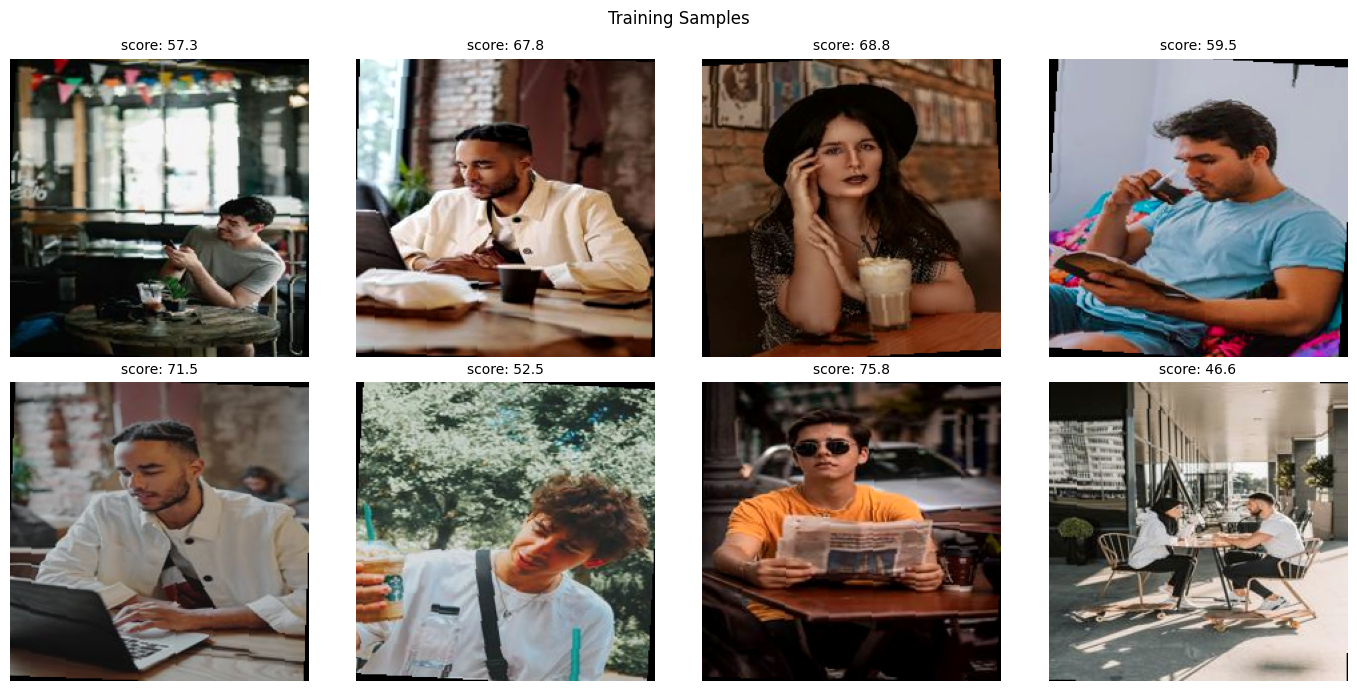

In [72]:
# Visualize sample batch
MEAN = torch.tensor([0.485,0.456,0.406])
STD  = torch.tensor([0.229,0.224,0.225])
def denorm(t): return (t * STD[:,None,None] + MEAN[:,None,None]).clamp(0,1)

imgs, boxes, scores = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs): ax.axis('off'); continue
    ax.imshow(denorm(imgs[i]).permute(1,2,0).numpy())
    ax.set_title(f'score: {scores[i].item():.1f}', fontsize=10)
    ax.axis('off')
plt.suptitle('Training Samples')
plt.tight_layout()
plt.show()

## 7 · Model

In [73]:
class AestheticScorer(nn.Module):
    def __init__(self, pretrained=True, freeze_backbone_layers=6,
                 roi_output_size=7, dropout=0.3):
        super().__init__()
        weights  = ResNet50_Weights.DEFAULT if pretrained else None
        backbone = resnet50(weights=weights)

        self.layer0 = nn.Sequential(backbone.conv1, backbone.bn1,
                                    backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        frozen = [self.layer0, self.layer1, self.layer2]
        if freeze_backbone_layers >= 4:
            frozen.append(self.layer3)
        for m in frozen:
            for p in m.parameters():
                p.requires_grad = False

        self.roi_output_size = roi_output_size
        self.global_pool     = nn.AdaptiveAvgPool2d(1)
        self.local_pool      = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Linear(4096, 512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512, 128),  nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 1), nn.Sigmoid(),
        )

    def extract_features(self, x):
        return self.layer4(self.layer3(self.layer2(self.layer1(self.layer0(x)))))

    def forward(self, images, boxes_norm):
        feat = self.extract_features(images)
        fH, fW = feat.shape[2:]
        global_feat = self.global_pool(feat).squeeze(-1).squeeze(-1)

        boxes_abs = boxes_norm.clone().float()
        boxes_abs[:,1] *= fW; boxes_abs[:,3] *= fW
        boxes_abs[:,2] *= fH; boxes_abs[:,4] *= fH

        roi_feats  = roi_align(feat, boxes_abs,
                               output_size=(self.roi_output_size, self.roi_output_size),
                               spatial_scale=1.0, aligned=True)
        local_feat = self.local_pool(roi_feats).squeeze(-1).squeeze(-1)

        img_idx = boxes_abs[:,0].long()
        fused   = torch.cat([global_feat[img_idx], local_feat], dim=1)
        return self.head(fused).squeeze(1) * 100.0


model = AestheticScorer(pretrained=True, freeze_backbone_layers=6).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total: {total:,}  |  Trainable: {trainable:,}  ({100*trainable/total:.1f}%)')

Total: 25,671,489  |  Trainable: 17,128,193  (66.7%)


## 8 · Loss Function Definition

In [74]:
class CombinedLoss(nn.Module):
    """MSE + pairwise ranking loss."""
    def __init__(self, margin=5.0, alpha=0.7):
        super().__init__()
        self.margin = margin
        self.alpha  = alpha

    def forward(self, pred, gt):
        mse = F.mse_loss(pred, gt)
        # Vectorised ranking loss over all pairs in batch
        p_i = pred.unsqueeze(1); p_j = pred.unsqueeze(0)
        g_i = gt.unsqueeze(1);   g_j = gt.unsqueeze(0)
        should_be_higher = (g_i > g_j).float()
        rank = (F.relu(self.margin - (p_i - p_j)) * should_be_higher).mean()
        loss = self.alpha * mse + (1 - self.alpha) * rank
        return loss, mse, rank


criterion = CombinedLoss(margin=5.0, alpha=0.7)

optimizer = torch.optim.AdamW([
    {'params': model.layer4.parameters(),  'lr': 1e-5},
    {'params': model.head.parameters(),    'lr': 1e-4},
    {'params': model.global_pool.parameters(), 'lr': 1e-4},
    {'params': model.local_pool.parameters(),  'lr': 1e-4},
], weight_decay=1e-4)

NUM_EPOCHS = 100
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)
print('Loss, optimizer, scheduler ready.')

Loss, optimizer, scheduler ready.


## 9 · Training Curves

In [75]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    tl = ml = rl = 0.0
    for imgs, boxes, scores in loader:
        imgs, boxes, scores = imgs.to(device), boxes.to(device), scores.to(device)
        preds = model(imgs, boxes)
        loss, mse, rank = criterion(preds, scores)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        tl += loss.item(); ml += mse.item(); rl += rank.item()
    n = len(loader)
    return tl/n, ml/n, rl/n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    tl = mae = 0.0
    all_p, all_g = [], []
    for imgs, boxes, scores in loader:
        imgs, boxes, scores = imgs.to(device), boxes.to(device), scores.to(device)
        preds = model(imgs, boxes)
        loss, _, _ = criterion(preds, scores)
        tl  += loss.item()
        mae += F.l1_loss(preds, scores).item()
        all_p.extend(preds.cpu().tolist())
        all_g.extend(scores.cpu().tolist())
    n    = len(loader)
    corr = float(np.corrcoef(all_p, all_g)[0,1]) if len(all_p) > 1 else 0.0
    return tl/n, mae/n, corr, all_p, all_g


history = {'train_loss':[], 'val_loss':[], 'val_mae':[], 'val_corr':[]}
best_val_loss = float('inf')

print(f'Training {NUM_EPOCHS} epochs | device={DEVICE} | train={len(df_train)} val={len(df_val)}')
print('='*72)

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_mse, tr_rank = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_mae, val_corr, _, _ = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    history['val_corr'].append(val_corr)

    marker = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({'epoch':epoch, 'model_state_dict':model.state_dict(),
                    'val_loss':val_loss, 'val_mae':val_mae, 'val_corr':val_corr},
                   os.path.join(CKPT_file, 'best_model.pth')) # Changed CKPT_DIR to CKPT_file
        marker = '  ← best'

    print(f'Ep {epoch:02d}/{NUM_EPOCHS} | '
          f'loss {tr_loss:.3f} (mse={tr_mse:.2f} rank={tr_rank:.2f}) | '
          f'val {val_loss:.3f} | MAE {val_mae:.2f} | r={val_corr:.3f} | '
          f'{time.time()-t0:.1f}s{marker}')

print('\nDone!')

Training 100 epochs | device=cuda | train=258 val=65
Ep 01/100 | loss 79.245 (mse=112.25 rank=2.24) | val 77.261 | MAE 7.83 | r=0.025 | 5.5s  ← best
Ep 02/100 | loss 48.877 (mse=68.95 rank=2.04) | val 44.895 | MAE 5.87 | r=0.089 | 6.6s  ← best
Ep 03/100 | loss 42.313 (mse=59.70 rank=1.75) | val 43.455 | MAE 5.80 | r=0.176 | 3.6s  ← best
Ep 04/100 | loss 38.988 (mse=54.97 rank=1.70) | val 43.393 | MAE 5.70 | r=0.189 | 3.2s  ← best
Ep 05/100 | loss 32.880 (mse=46.35 rank=1.44) | val 50.021 | MAE 6.05 | r=0.207 | 2.9s
Ep 06/100 | loss 30.602 (mse=43.19 rank=1.22) | val 44.517 | MAE 5.45 | r=0.240 | 6.9s
Ep 07/100 | loss 24.463 (mse=34.45 rank=1.16) | val 50.831 | MAE 6.01 | r=0.250 | 3.9s
Ep 08/100 | loss 20.650 (mse=29.08 rank=0.98) | val 42.662 | MAE 5.20 | r=0.269 | 2.9s  ← best
Ep 09/100 | loss 19.877 (mse=27.99 rank=0.95) | val 45.266 | MAE 5.40 | r=0.275 | 3.1s
Ep 10/100 | loss 16.781 (mse=23.60 rank=0.87) | val 46.060 | MAE 5.52 | r=0.272 | 4.1s
Ep 11/100 | loss 17.153 (mse=24.10 r

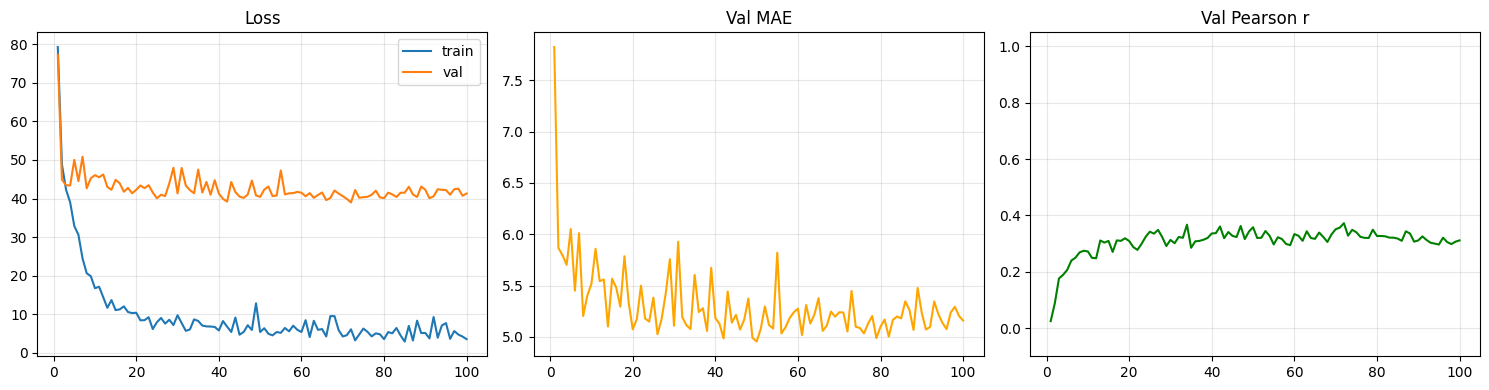

Best MAE: 4.95  |  Best Pearson r: 0.372


In [76]:
ep = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].plot(ep, history['train_loss'], label='train')
axes[0].plot(ep, history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_mae'], color='orange')
axes[1].set_title('Val MAE'); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['val_corr'], color='green')
axes[2].set_title('Val Pearson r'); axes[2].set_ylim(-0.1, 1.05); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Best MAE: {min(history["val_mae"]):.2f}  |  Best Pearson r: {max(history["val_corr"]):.3f}')

## 10. Model Evaluation 


Best model: epoch 72 | MAE 5.05 | r=0.372


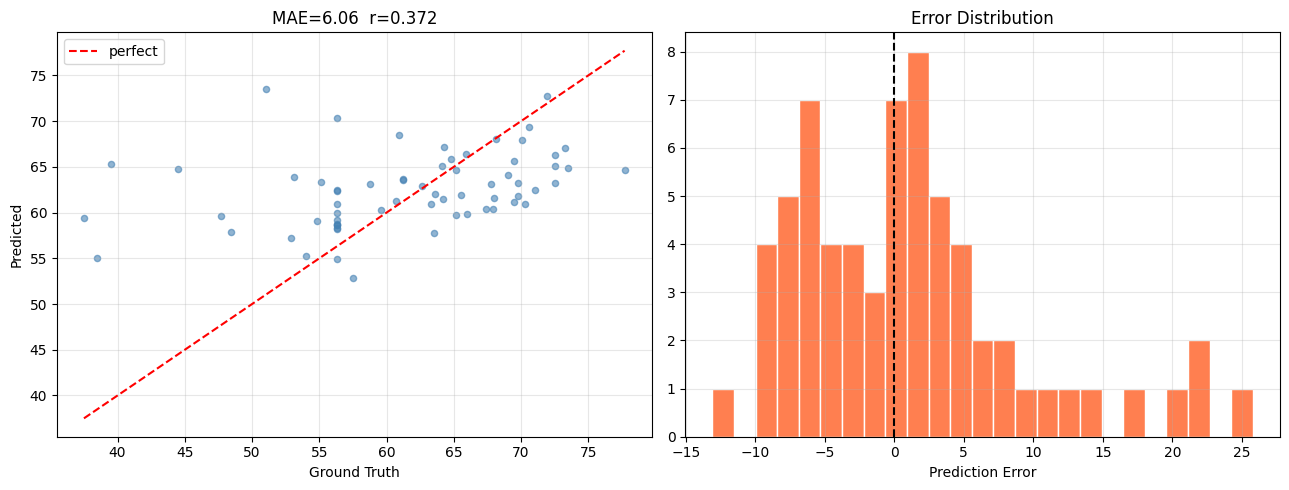

In [77]:
ckpt = torch.load(os.path.join(CKPT_file, 'best_model.pth'), map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Best model: epoch {ckpt["epoch"]} | MAE {ckpt["val_mae"]:.2f} | r={ckpt["val_corr"]:.3f}')

_, _, _, all_preds, all_gt = validate(model, val_loader, criterion, DEVICE)
all_preds = np.array(all_preds); all_gt = np.array(all_gt)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Scatter
axes[0].scatter(all_gt, all_preds, alpha=0.6, s=20, color='steelblue')
lo,hi = min(all_gt.min(),all_preds.min()), max(all_gt.max(),all_preds.max())
axes[0].plot([lo,hi],[lo,hi],'r--',lw=1.5,label='perfect')
mae  = np.abs(all_preds-all_gt).mean()
arr = np.corrcoef(all_preds,all_gt)[0,1]
axes[0].set_xlabel('Ground Truth'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'MAE={mae:.2f}  r={arr:.3f}'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Error distribution
errors = all_preds - all_gt
axes[1].hist(errors, bins=25, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Prediction Error'); axes[1].set_title('Error Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 11 · Inference on New Images

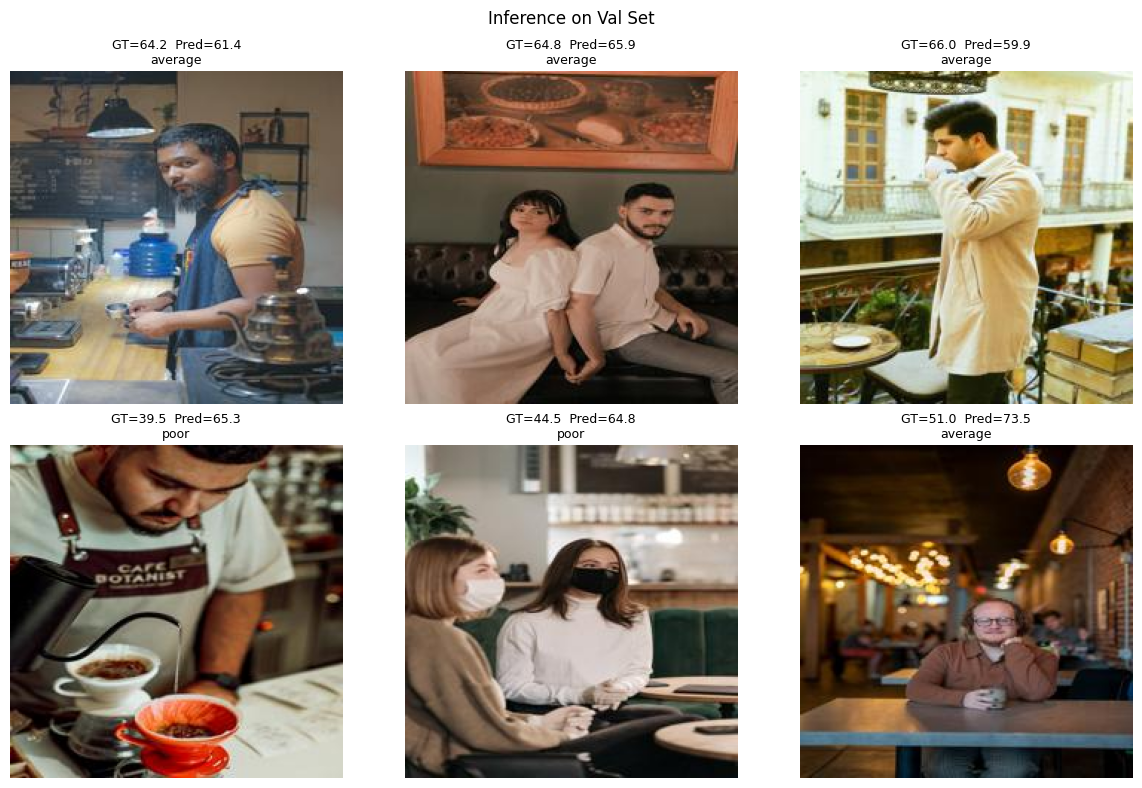

In [78]:
def infer_image(img_path, bbox_norm=None):
    """Score a single image. bbox_norm=[x1,y1,x2,y2] normalized, default=full image."""
    model.eval()
    img    = Image.open(img_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(DEVICE)
    if bbox_norm is None:
        bbox_norm = [0.0, 0.0, 1.0, 1.0]
    box = torch.tensor([[0.0]+bbox_norm], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        score = model(tensor, box)
    return round(score.item(), 2)


# Score a few val images
sample = df_val.head(6)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img_path = Path(IMG_DIR) / row['filename']
    pred = infer_image(img_path)
    img  = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'GT={row["score"]:.1f}  Pred={pred:.1f}\n{row["quality_label"]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Inference on Val Set')
plt.tight_layout(); plt.show()